# 3.0 CPA — 프로파일링 없이 키 복구 · Normal ∥ Masked

## 이 노트북이 답하는 질문

**타겟과 똑같은 장비를 미리 확보하지 못한 상태에서 키를 꺼낼 수 있는가?**

`scalib.attacks.Cpa` 는 상관 전력 분석(Correlation Power Analysis)을 수행한다.
프로파일링 단계가 없어 **공격자가 준비할 것이 적다** — 필요한 것은 평문과 트레이스뿐이다.

여기까지(1.0, 2.0, 2.1)는 전부 **진단**이었다. 이 노트북부터는 실제로 키를 복구한다.

| | |
|---|---|
| 입력 | 타겟별 `/attack` (고정 키 · 랜덤 평문 10,000장) |
| 성공 판정 | 루트 HDF5 attrs의 정답 키 16바이트를 **전부** 맞히는가 |
| 하드웨어 | 불필요. `1.0.SNR` 선행 필요 (`enc_start`) |

## 원리

키 한 바이트를 $k$ 라 하고 그 값을 256가지로 **추측**한다. 추측 $g$ 마다 중간값을 계산하고,

$$ v_i(g) = \mathrm{SBOX}[\ p_i \oplus g\ ] $$

그 값이 만들 법한 전력을 **누설 모델**로 예측한다(여기서는 해밍 가중치 $\mathrm{HW}(v)$).
그런 다음 시점 $j$마다 실제 트레이스와의 **피어슨 상관계수**를 잰다.

$$ \rho_{g,j} = \mathrm{corr}\big(\ \mathrm{HW}(v_i(g))\ ,\ l_{i,j}\ \big) $$

추측이 맞으면 예측과 실제가 같은 이유로 움직이므로 어느 시점에서 상관이 크게 튄다.
틀리면 S-box 의 비선형성 때문에 예측이 사실상 무작위가 되어 상관이 낮게 깔린다.

**바이트마다 독립으로 256번만 시도**하면 되므로, $2^{128}$ 이 아니라 $16 \times 256$ 번의 계산이다.

## 마스킹은 이 논리의 어디를 끊는가

마스킹된 구현에서 레지스터에 실제로 실리는 값은 $\mathrm{SBOX}[p \oplus k] \oplus m$ 이다
(1.0 §10 에서 구현으로부터 유도했다). 공격자는 $m$ 을 모르므로 $\mathrm{HW}(\mathrm{SBOX}[p \oplus g])$
를 예측으로 쓸 수밖에 없는데, $m$ 이 매 암호화마다 새로 뽑히는 균일 난수라면
그 예측과 실제 누설의 상관은 **정답 추측에서도 0 으로 수렴한다.**

즉 마스킹은 모델을 틀리게 만드는 것이 아니라 **모델이 가리키는 값이 트레이스에 없게** 만든다.

---
## 1. `Cpa` API

| 단계 | 코드 |
|:----:|------|
| 생성 | `cpa = Cpa(nc=256, kind=Cpa.IntermediateKind.Xor)` |
| 누적 | `cpa.fit_u(traces, labels)` — 라벨은 **평문** `(n, nv)` `uint16` |
| 결과 | `cpa.get_correlation(models)` → `(nv, nc, ns)` |

`kind` 는 라벨과 키 추측을 어떻게 합치는지를 정한다.

| `kind` | 중간값 |
|--------|--------|
| `Cpa.IntermediateKind.Xor` | `label ^ guess` |
| `Cpa.IntermediateKind.Add` | `(label + guess) mod nc` |

즉 **라벨은 평문 바이트**이고, `models[v][j]` 는 "중간값이 $j$ 일 때의 예측 누설" 이다.
우리는 SBox 출력의 해밍 가중치를 노리므로 `models[v][j] = HW[SBOX[j]]` 가 된다.
(`Cpa.Xor` 는 `Cpa.IntermediateKind.Xor` 의 짧은 이름이다 — 같은 객체다.)

> **라벨 shape 규약이 API 마다 다르다.** 문서에 정리되어 있지 않고 실행해 봐야 알 수 있어
> 여기 적어 둔다. 틀리면 `ValueError: The classes array has N dimensions` 가 난다.
>
> | API | 라벨 shape | dtype |
> |-----|-----------|-------|
> | `Ttest` | `(n,)` | `uint16` |
> | `SNR`, `Cpa`, `MultiLDA` | `(n, nv)` | `uint16` |
> | `LDAClassifier` | `(n,)` | `uint16` |
> | `RLDAClassifier` | `(n, nv)` | `uint64` |
> | `RLDAInformationEstimator` | `(n,)` | `uint64` |
>
> 트레이스(`traces`)는 어디서나 `(n, ns)` `int16`이다.

### 메모리 주의 — 창을 잘라야 하는 이유

`get_correlation` 은 `(nv, nc, ns)` `float64` 를 통째로 만든다. Masked 의 암호화 구간
50,000 샘플을 그대로 넣으면 $16 \times 256 \times 50000 \times 8 \approx 1.6$ TB 다.
반드시 구간을 잘라 넣어야 한다.

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["font.family"] = "NanumGothic"
matplotlib.rcParams["axes.unicode_minus"] = False

from scalib_common import (
    TARGETS, TARGET_IDS, SBOX, HW, AES_BLOCK, sbox_out,
    load_group, load_poi, dataset_summary, require_target,
)
from scalib.attacks import Cpa

data, poi = {}, {}
for tid in TARGET_IDS:
    if not require_target(tid)["dataset"].is_file():
        print("[%s] 데이터셋 없음 — skip" % TARGETS[tid]["short"]); continue
    data[tid] = load_group("attack", target=tid)
    poi[tid] = load_poi(tid)
    d = data[tid]
    print("[%s] attack%s  키 고정: %s  enc_start=%d" % (
        TARGETS[tid]["short"], d["t"].shape,
        len(np.unique(d["k"], axis=0)) == 1, int(poi[tid]["enc_start"])))

if not data:
    raise FileNotFoundError("데이터셋이 없다.")

TRUE_KEY = np.array(data[TARGET_IDS[0]]["attrs"]["fixed_key"], dtype=np.uint8)
print()
print("정답 키:", " ".join("%02x" % b for b in TRUE_KEY))
print("(정답을 아는 이유: 이 데이터셋은 교육용이라 attrs 에 기록해 두었다.")
print(" 실제 공격에서는 모르며, 아래 절차는 정답을 전혀 쓰지 않는다 — 채점에만 쓴다.)")

[Normal] attack(10000, 33172)  키 고정: True  enc_start=5093


[Masked] attack(10000, 55184)  키 고정: True  enc_start=5089

정답 키: 2f 6b 07 31 d3 e2 66 7f 26 85 42 9f 35 dc 5d d1
(정답을 아는 이유: 이 데이터셋은 교육용이라 attrs 에 기록해 두었다.
 실제 공격에서는 모르며, 아래 절차는 정답을 전혀 쓰지 않는다 — 채점에만 쓴다.)


---
## 2. 어디를 볼 것인가 — 창을 고르지 않고 전 구간을 훑는다

1.0 이 POI 를 저장해 두었으니 그 근방만 보면 빠르다. 그런데 **Masked 의 POI 는 잡음에서
고른 값**이다 (1.0 §6: SNR 이 바닥과 구분되지 않았다). 그 창만 보고 "실패했다" 고 하면
"창을 잘못 골라서 실패한 것 아니냐" 는 반문에 답할 수 없다.

그래서 두 타겟 모두 **암호화 구간 전체를 청크로 나눠 훑는다.** 청크마다 상관을 구하고
바이트별 최대 상관만 남긴다. 메모리는 청크 크기로 묶이고, 결과는 "전 구간 어디에도
쓸 만한 상관이 없었다" 를 보장한다.

이것은 실제 공격자가 하는 일과 같다 — 공격자에게는 SNR 을 재어 줄 알려진 키가 없다.

In [2]:
CHUNK = 2500
N_USE = 5000


def cpa_scan(tid, n_use=N_USE, chunk=CHUNK, model_1d=None, verbose=True):
    """암호화 구간을 청크로 훑어 바이트별 최고 |상관| (16, 256) 을 구한다."""
    d = data[tid]
    lo = int(poi[tid]["enc_start"])
    ns = d["t"].shape[1]
    x = d["p"][:n_use].astype(np.uint16)
    if model_1d is None:
        model_1d = HW[SBOX].astype(np.float64)     # HW(SBOX[중간값])

    best = np.zeros((AES_BLOCK, 256))
    for s in range(lo, ns, chunk):
        e = min(s + chunk, ns)
        cpa = Cpa(nc=256, kind=Cpa.IntermediateKind.Xor)
        cpa.fit_u(np.ascontiguousarray(d["t"][:n_use, s:e]), x)
        models = np.broadcast_to(
            np.asarray(model_1d, dtype=np.float64).reshape(1, 256, 1),
            (AES_BLOCK, 256, e - s)).copy()
        best = np.maximum(best, np.nanmax(np.abs(cpa.get_correlation(models)), axis=2))
    if verbose:
        print("[%s] %d장, 구간 %d~%d 를 %d개 청크로 훑음"
              % (TARGETS[tid]["short"], n_use, lo, ns, (ns - lo + chunk - 1) // chunk))
    return best


def ranks_of(best, true_key=None):
    """정답 키의 순위 (0 = 1등). 채점 전용."""
    true_key = TRUE_KEY if true_key is None else true_key
    return np.array([int(np.where(np.argsort(-best[b]) == true_key[b])[0][0])
                     for b in range(AES_BLOCK)])


scores, rank_map = {}, {}
for tid in data:
    scores[tid] = cpa_scan(tid)
    rank_map[tid] = ranks_of(scores[tid])

[Normal] 5000장, 구간 5093~33172 를 12개 청크로 훑음


[Masked] 5000장, 구간 5089~55184 를 21개 청크로 훑음


---
## 3. 키 복구 결과

In [3]:
for tid in scores:
    best, ranks = scores[tid], rank_map[tid]
    recovered = best.argmax(axis=1).astype(np.uint8)
    top = best.max(axis=1)
    second = np.sort(best, axis=1)[:, -2]
    ok = recovered == TRUE_KEY

    print("=== %s ===" % TARGETS[tid]["short"])
    print("바이트  복구  정답   1등 |rho|   2등 |rho|    격차   순위   판정")
    for i in range(AES_BLOCK):
        print("  %2d     %02x    %02x     %.4f     %.4f   %+.4f   %4d    %s"
              % (i, recovered[i], TRUE_KEY[i], top[i], second[i],
                 top[i] - second[i], ranks[i], "O" if ok[i] else "X"))
    print("  복구한 키: " + " ".join("%02x" % b for b in recovered))
    print("  === %d / %d 바이트 일치 — 키 복구 %s ===   (정답 평균 순위 %.1f)"
          % (ok.sum(), AES_BLOCK, "성공" if ok.all() else "실패", ranks.mean()))
    print()

if len(rank_map) == 2:
    print("[비교]")
    for tid in rank_map:
        r = rank_map[tid]
        print("  %-8s 1등으로 맞힌 바이트 %2d/16, 정답 평균 순위 %6.1f"
              % (TARGETS[tid]["short"], int((r == 0).sum()), r.mean()))
    print()
    print("  무작위로 찍으면 정답 평균 순위는 127.5 다.")
    print("  Masked 의 평균 순위가 그 근처라면, 이 공격은 아무 정보도 얻지 못했다는 뜻이다.")

=== Normal ===
바이트  복구  정답   1등 |rho|   2등 |rho|    격차   순위   판정
   0     2f    2f     0.6839     0.1927   +0.4912      0    O
   1     6b    6b     0.6701     0.1967   +0.4734      0    O
   2     07    07     0.6692     0.2069   +0.4623      0    O
   3     31    31     0.6687     0.2358   +0.4330      0    O
   4     d3    d3     0.6727     0.2158   +0.4569      0    O
   5     e2    e2     0.6819     0.2108   +0.4711      0    O
   6     66    66     0.6539     0.2040   +0.4498      0    O
   7     7f    7f     0.6681     0.2060   +0.4621      0    O
   8     26    26     0.6857     0.2028   +0.4829      0    O
   9     85    85     0.6692     0.2089   +0.4603      0    O
  10     42    42     0.6933     0.2155   +0.4778      0    O
  11     9f    9f     0.6832     0.2437   +0.4395      0    O
  12     35    35     0.6852     0.2199   +0.4653      0    O
  13     dc    dc     0.6644     0.2306   +0.4337      0    O
  14     5d    5d     0.6763     0.2063   +0.4700      0    O
  15 

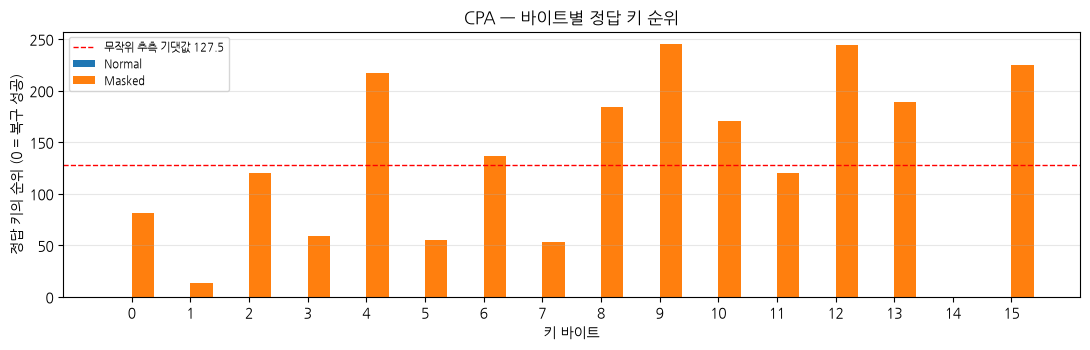

In [4]:
fig, ax = plt.subplots(figsize=(11, 3.6))
x = np.arange(AES_BLOCK)
w = 0.38 if len(rank_map) == 2 else 0.6
for i, tid in enumerate(rank_map):
    off = (i - (len(rank_map) - 1) / 2) * w
    ax.bar(x + off, rank_map[tid], w, label=TARGETS[tid]["short"])
ax.axhline(127.5, color="r", ls="--", lw=1, label="무작위 추측 기댓값 127.5")
ax.set_xlabel("키 바이트"); ax.set_ylabel("정답 키의 순위 (0 = 복구 성공)")
ax.set_xticks(x); ax.set_title("CPA — 바이트별 정답 키 순위")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis="y")
fig.tight_layout(); plt.show()

---
## 4. 몇 장이면 되는가

CPA 의 실용성은 "얼마나 적은 트레이스로 성공하는가" 로 잰다.
트레이스 수를 늘려 가며 **몇 바이트가 맞는지**를 본다.

Masked 쪽 곡선이 트레이스 수를 늘려도 올라가지 않는 것이 핵심이다 — 정보가 적은 것이 아니라
**이 모델로는 없는** 것이라, 트레이스 수를 늘려도 수렴할 대상이 없다.

[Normal  ] 200장:16  500장:16  1000장:16  2000장:16  5000장:16  10000장:16


[Masked  ] 200장:0  500장:0  1000장:0  2000장:1  5000장:1  10000장:1


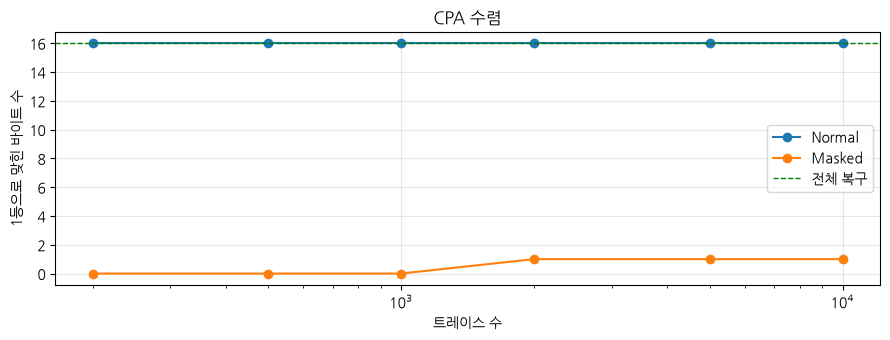

In [5]:
COUNTS = [200, 500, 1000, 2000, 5000, 10000]

curve = {}
for tid in data:
    hits = []
    for m in COUNTS:
        m = min(m, data[tid]["t"].shape[0])
        r = ranks_of(cpa_scan(tid, n_use=m, verbose=False))
        hits.append(int((r == 0).sum()))
    curve[tid] = hits
    print("[%-8s] " % TARGETS[tid]["short"]
          + "  ".join("%d장:%d" % (c, h) for c, h in zip(COUNTS, hits)))

fig, ax = plt.subplots(figsize=(9, 3.5))
for tid in curve:
    ax.plot(COUNTS, curve[tid], "o-", label=TARGETS[tid]["short"])
ax.axhline(16, color="g", ls="--", lw=1, label="전체 복구")
ax.set_xscale("log"); ax.set_xlabel("트레이스 수"); ax.set_ylabel("1등으로 맞힌 바이트 수")
ax.set_title("CPA 수렴"); ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout(); plt.show()

---
## 5. 누설 모델을 바꾸면

해밍 가중치는 **가정**이다. 타겟이 실제로 그렇게 새지 않으면 공격이 약해진다.
다른 모델과 비교해 이 가정이 이 타겟에 맞는지 확인한다.

| 모델 | 뜻 |
|------|-----|
| `HW(SBOX[v])` | S-box 출력의 1비트 개수 — 레지스터에 값이 실릴 때의 전력 |
| `SBOX[v] & 1` | 최하위 비트 하나만 — 정보량이 적다 |
| `HW(v)` | S-box **입력**의 1비트 개수 — 비선형을 안 거친 값 |

성공/실패만 보면 모델의 차이가 잘 안 보인다. 보호되지 않은 타겟에 트레이스가 충분하면
어설픈 모델로도 정답이 1등을 하기 때문이다. 차이는 **여유**에서 드러나므로
1등과 2등 상관의 격차를 함께 잰다 — 격차가 작을수록 잡음에 쉽게 뒤집힌다.

특히 `HW(v)` 를 눈여겨보라. S-box 를 거치지 않으면 서로 다른 키 추측이 **같은 예측 집합**을
만들어 상관이 동률이 된다. CPA 가 비선형 연산 뒤의 값을 겨냥하는 이유가 여기 있다.

Masked 에서는 어느 모델을 써도 달라지지 않아야 한다. 모델이 틀린 것이 아니라
**겨냥한 값 자체가 Trace(트레이스)에 없기** 때문이다.

In [6]:
v = np.arange(256)
MODELS = (
    ("HW(SBOX[v])  (기본)", HW[SBOX[v]]),
    ("SBOX[v] 의 LSB", SBOX[v] & 1),
    ("HW(v)  S-box 입력", HW[v]),
)

print("%-8s %-24s %8s %10s %12s" % (
    "타겟", "누설 모델", "맞은수", "평균 순위", "평균 격차"))
for tid in data:
    for name, mdl in MODELS:
        best = cpa_scan(tid, n_use=2000, model_1d=mdl, verbose=False)
        r = ranks_of(best)
        srt = np.sort(best, axis=1)
        margin = float(np.mean(srt[:, -1] - srt[:, -2]))
        print("%-8s %-24s %6d/16 %10.1f %12.4f" % (
            TARGETS[tid]["short"], name, int((r == 0).sum()), r.mean(), margin))
    print()

print("Normal — 기본 모델의 격차가 압도적이다. LSB 모델도 정답을 1등에 올리지만")
print("  격차가 훨씬 작아 그만큼 잡음과 장수 부족에 약하다.")
print("  HW(v) 는 격차가 0 이다: S-box 를 안 거친 값이라 서로 다른 키 추측이 같은")
print("  예측 집합을 만들어 상관이 동률이 된다. 1등이 나와도 동률 처리의 우연일 뿐,")
print("  이 모델로는 키를 가릴 수 없다 — CPA 에 비선형이 필요한 이유가 이것이다.")
print("Masked — 모델을 바꿔도 순위가 무작위 근처에 머물고 격차도 사실상 0 이다.")
print("  모델의 문제가 아니라 겨냥한 값이 파형에 없다.")

타겟       누설 모델                         맞은수      평균 순위        평균 격차


Normal   HW(SBOX[v])  (기본)            16/16        0.0       0.4576


Normal   SBOX[v] 의 LSB                16/16        0.0       0.0607


Normal   HW(v)  S-box 입력               9/16        0.4       0.0000



Masked   HW(SBOX[v])  (기본)             1/16      123.3       0.0071


Masked   SBOX[v] 의 LSB                 2/16      117.4       0.0043


Masked   HW(v)  S-box 입력               0/16      117.2       0.0000

Normal — 기본 모델의 격차가 압도적이다. LSB 모델도 정답을 1등에 올리지만
  격차가 훨씬 작아 그만큼 잡음과 장수 부족에 약하다.
  HW(v) 는 격차가 0 이다: S-box 를 안 거친 값이라 서로 다른 키 추측이 같은
  예측 집합을 만들어 상관이 동률이 된다. 1등이 나와도 동률 처리의 우연일 뿐,
  이 모델로는 키를 가릴 수 없다 — CPA 에 비선형이 필요한 이유가 이것이다.
Masked — 모델을 바꿔도 순위가 무작위 근처에 머물고 격차도 사실상 0 이다.
  모델의 문제가 아니라 겨냥한 값이 파형에 없다.


---
## 6. 연구자 관점 — 마스킹 난수를 안다면

1.0 §10 에서 라벨 하나 바꾸는 것만으로 누설이 되살아나는 것을 보았다.
CPA 에서도 같은 일이 되는지 확인한다. 예측 모델을 이렇게 바꾸면 된다.

$$ \mathrm{HW}\big(\ \mathrm{SBOX}[p_i \oplus g] \oplus m_{5,i}\ \big) $$

### 그런데 `Cpa` API 로는 이것을 표현할 수 없다

`get_correlation(models)` 의 `models` 는 `(nv, nc, ns)` 짜리 **정적인 표**다.
"중간값이 $j$ 이면 예측 누설은 이 값" 이라는 대응이 **모든 트레이스에 대해 같아야** 한다.

그런데 $m_5$ 는 **트레이스마다 다르다.** 같은 중간값이라도 트레이스에 따라 예측이 달라져야
하므로 정적 표에 담을 수 없다. `nc` 를 $256 \times 256$ 으로 늘리는 우회도 가능하지만
라벨 정의가 뒤틀린다.

이럴 때는 SCALib 을 억지로 쓰지 말고 **상관계수를 직접 계산**한다. CPA 는 결국 피어슨
상관일 뿐이고, 예측 행렬 `(n, 256)` 을 만들 수 있으면 numpy 로 몇 줄이다.

> **교훈:** 라이브러리 API 의 형태가 곧 공격의 한계는 아니다.
> `Cpa` 는 "모델이 트레이스에 무관하다" 를 전제로 최적화된 도구이고, 그 전제가 깨지면
> 도구를 바꾼다. 4.0 의 LDA 는 라벨이 트레이스별이라 이 문제가 없다 — 거기서 대비된다.

In [7]:
def cpa_numpy(traces, pred):
    """상관계수를 직접 계산한다. traces (n, ns), pred (n, 256) → (256, ns)."""
    t = traces.astype(np.float64)
    t -= t.mean(axis=0)
    p = pred.astype(np.float64)
    p -= p.mean(axis=0)
    num = p.T @ t                                   # (256, ns)
    den = np.outer(np.linalg.norm(p, axis=0), np.linalg.norm(t, axis=0))
    return np.abs(num / np.maximum(den, 1e-30))


tid = "masked-aes-c"
if tid not in data or data[tid]["m"] is None:
    print("Masked HDF5 `mask` 배열 없음 — 연구자 절 건너뜀")
else:
    d = data[tid]
    z = poi[tid]
    m5 = d["m"][:, 5].astype(np.uint8)
    G = np.arange(256, dtype=np.uint8)
    HALF = 10

    ranks_known, ranks_blind = [], []
    for b in range(AES_BLOCK):
        c = int(z["poi_research"][b])
        w = slice(max(0, c - HALF), c + HALF + 1)
        seg = d["t"][:, w]
        sb = SBOX[np.bitwise_xor(d["p"][:, b][:, None], G[None, :])]   # (n, 256)

        known = cpa_numpy(seg, HW[np.bitwise_xor(sb, m5[:, None])]).max(axis=1)
        blind = cpa_numpy(seg, HW[sb]).max(axis=1)
        ranks_known.append(int(np.where(np.argsort(-known) == TRUE_KEY[b])[0][0]))
        ranks_blind.append(int(np.where(np.argsort(-blind) == TRUE_KEY[b])[0][0]))

    ranks_known = np.array(ranks_known); ranks_blind = np.array(ranks_blind)
    print("같은 파형·같은 창·같은 상관 계산. 예측 모델에 m5 를 넣었는가만 다르다.\n")
    print("%-28s %8s %12s" % ("모델", "맞은수", "평균 순위"))
    print("%-28s %6d/16 %12.1f" % ("HW(SBOX[p^g])        (공격자)",
                                   int((ranks_blind == 0).sum()), ranks_blind.mean()))
    print("%-28s %6d/16 %12.1f" % ("HW(SBOX[p^g] ^ m5)   (연구자)",
                                   int((ranks_known == 0).sum()), ranks_known.mean()))
    print()
    print("바이트별 순위 (공격자):", ranks_blind.tolist())
    print("바이트별 순위 (연구자):", ranks_known.tolist())
    print()
    print("마스킹의 안전성은 알고리즘이 아니라 **난수의 비밀성**에 걸려 있다.")
    print("난수가 새면(RNG 결함·시드 고정·부채널) 같은 파형에서 키가 나온다.")

같은 파형·같은 창·같은 상관 계산. 예측 모델에 m5 를 넣었는가만 다르다.

모델                                맞은수        평균 순위
HW(SBOX[p^g])        (공격자)        0/16        173.1
HW(SBOX[p^g] ^ m5)   (연구자)       16/16          0.0

바이트별 순위 (공격자): [211, 7, 138, 192, 201, 119, 95, 241, 105, 228, 254, 251, 182, 213, 243, 90]
바이트별 순위 (연구자): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

마스킹의 안전성은 알고리즘이 아니라 **난수의 비밀성**에 걸려 있다.
난수가 새면(RNG 결함·시드 고정·부채널) 같은 파형에서 키가 나온다.


---
## 7. 요약

| 항목 | 내용 |
|------|------|
| 목적 | **프로파일링 없이** 키를 복구한다 |
| API | `Cpa(nc, kind)` → `fit_u(traces, labels)` → `get_correlation(models)` |
| `labels` | `(n, nv)` `uint16` — **알려진 값(평문)**. 키가 아니다 |
| `models` | `(nv, nc, ns)` `float64` — 중간값별 예측 누설. **트레이스에 무관해야 한다** |
| `kind` | `Xor` (중간값 = label ^ guess) 또는 `Add` |
| 결과 | `(nv, nc, ns)` 상관. 바이트별 `argmax` 가 복구한 키 |
| 메모리 | `(nv, nc, ns)` 를 통째로 만든다 — 반드시 구간을 잘라 넣는다 |

### 이 Dataset(데이터셋)에서 관측한 것

| 타겟 | 결과 |
|------|------|
| Normal | 전 구간 스캔으로 16/16 복구. 수천 장이면 충분하다 |
| Masked (공격자) | 0/16. 정답 평균 순위가 무작위 기댓값 근처. 모델을 바꿔도, 트레이스 수를 늘려도 같다 |
| Masked (연구자) | 마스크를 예측에 넣으면 **같은 트레이스에서** 키가 복구된다 |

### 실패 시 점검

1. 라벨에 **키**를 넣으면 안 된다. 공격자는 키를 모른다 — 평문을 넣는다.
2. `models` 의 축 순서가 `(nv, nc, ns)` 인지 확인한다.
3. 메모리 부족 → 청크를 줄인다. `(16, 256, ns)` `float64` 가 통째로 잡힌다.
4. 아무 바이트도 안 맞는다 → 누설 모델이 타겟과 안 맞거나, **대책이 걸려 있다.**
   둘을 가르려면 1.0 SNR 로 그 중간값이 애초에 새는지부터 확인한다.
5. 일부만 맞는다 → Trace 수를 단계적으로 늘리며 정답 키 순위가 안정적으로 내려가는지 확인한다.

다음: `4.0.LDAClassifier.ipynb` — 타겟을 미리 프로파일링하면 얼마나 강해지는가.